In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
pic = cv2.imread("/home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/data/photos/pushup/correct/pushp.jpg")

In [8]:
gray = cv2.cvtColor(pic, cv2.COLOR_BGR2GRAY)    
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(blurred)
edges = cv2.Canny(enhanced, threshold1=50, threshold2=150)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Close small gaps in edges
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# Remove small noise
cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

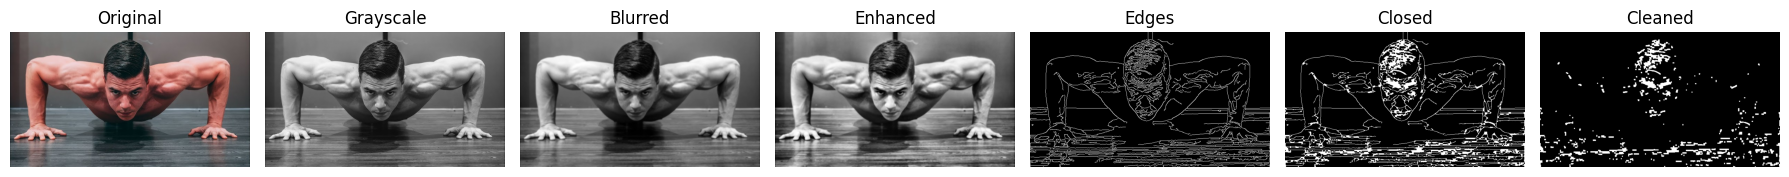

In [23]:
titles = ["Original", "Grayscale", "Blurred", "Enhanced", "Edges", "Closed", "Cleaned"]
images = [
    cv2.cvtColor(pic, cv2.COLOR_BGR2RGB),
    gray, blurred, enhanced, edges, closed, cleaned
]

plt.figure(figsize=(18, 7))
for i, (title, img) in enumerate(zip(titles, images)):
    plt.subplot(1, 7, i + 1)
    plt.imshow(img, cmap="gray" if len(img.shape) == 2 else None)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()